# Rollout GIFs

Rollouts on auxetic (`nu < -0.1`) sims from `new_node_optimized` (1500 frame trajectories, unseen by the models) with the simulator cascade and the bootstrapped GNN simulator, each with and without ITPO.
Short rollouts record final position MSE and Poisson's ratio error to pick the sim where each simulator does best.
That sim is then rolled out much longer and GT vs predicted trajectory is rendered overlaid as a GIF, so divergence becomes visible.

In [1]:
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from matplotlib import patches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from torch_geometric.data import Data
from tqdm import tqdm

import barostat_parameters
import itpo_weights
from graph_utils import prepare_traj
from ift import specialized_rollout_implicit
from itpo_weights import DatasetType, ModelType
from simulator_SA_cpu_test import Model as VelocityModel
from training_utils import freeze_normalizer
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    load_and_split_dataset,
    rollout_cascade,
    simulate_then_rollout,
    specialized_rollout_cascade,
)

### Data

In [2]:
dataset_type = DatasetType.NodeOptimized
search_steps = 100  # rollout length used to pick the best sim
gif_steps = 1499    # rollout length for the GIFs: full 1500 frame sims, 3% strain
gif_durations = (2.0, 1.0)  # total GIF length in seconds, one copy each
max_p = -0.1        # auxetic networks only

# new_node_optimized is not part of the models' training data, so every sim is a test sim
registry = pd.read_csv("./data/new_node_optimized/data_registry.csv")
test_files = registry[(registry["data_type"] == f"{dataset_type}") & (registry["poisson_ratio"] < max_p)]["file_path"].tolist()

# Original node_optimized data (500 frame sims, max 499 GIF steps): test split of ITPO_demo
# poisson_buckets = [
#     {"max": 0.1, "count": 300},             # P < 0.1
#     {"min": 0.1, "max": 0.2, "count": 100}, # 0.1 <= P < 0.2
#     {"min": 0.2, "count": 100}              # P >= 0.2
# ]
# train_files, val_files, test_files = load_and_split_dataset(
#     registry_path="./data/data_registry.csv",
#     target_data_type=dataset_type,
#     possion_buckets=poisson_buckets,
#     split_ratios=(0.5, 0.25, 0.25),
#     seed=42
# )
# registry = pd.read_csv("./data/data_registry.csv").set_index("file_path")
# test_files = [file for file in test_files if registry.loc[file, "poisson_ratio"] < max_p]

# Full length sims so the long GIF rollouts have GT for every step
data = {
    "test": [
        prepare_traj(torch.load(file, weights_only=False), None, calc_angles=False)
        for file in tqdm(test_files, desc="test  data")
    ]
}
print(f"Auxetic test data: {len(data['test'])} sims.")

test  data:   0%|          | 0/12 [00:00<?, ?it/s]

test  data:   8%|▊         | 1/12 [00:00<00:03,  3.48it/s]

test  data:  17%|█▋        | 2/12 [00:00<00:03,  2.84it/s]

test  data:  25%|██▌       | 3/12 [00:00<00:02,  3.06it/s]

test  data:  33%|███▎      | 4/12 [00:01<00:02,  3.20it/s]

...

test  data:  83%|████████▎ | 10/12 [00:03<00:00,  3.10it/s]

test  data:  92%|█████████▏| 11/12 [00:03<00:00,  2.80it/s]

test  data: 100%|██████████| 12/12 [00:04<00:00,  2.93it/s]

test  data: 100%|██████████| 12/12 [00:04<00:00,  2.97it/s]

Auxetic test data: 12 sims.


### Load pretrained models

In [3]:
device = "cuda"
hidden_size = 128
mp_layers = 2
mlp = 3

# Simulator cascade
epochs = 100
model_save_path = os.path.join("./trained_models", f"{dataset_type}", "cascade", "refined")
n_models = len(os.listdir(model_save_path))

cascade_models = []
for h in tqdm(range(n_models)):
    if h == 0:
        n_graphs = 1
    else:
        n_graphs = h+1

    init_graph = build_velocity_graph_correction([data['test'][0][i].cpu().detach() for i in range(n_graphs)], panic_at_positions=False).to(device)

    current_h_model = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
    current_h_model.load_checkpoint(os.path.join(model_save_path, f"model_refined_h{h}_nl{mp_layers}_mlp{mlp}_epochs{epochs}.pt"))
    current_h_model = freeze_normalizer(current_h_model)
    for param in current_h_model.parameters():
        param.requires_grad = False
    cascade_models.append(current_h_model)

print(f"Loaded cascade of {len(cascade_models)} pretrained models.")

# Bootstrapped GNN simulator
history = 3
init_graph = Data(x=torch.ones((100, history*2)), edge_attr=torch.ones((100, 4)))
gnn_model: VelocityModel = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)
gnn_model.load_checkpoint(f"./new_trained_models/{dataset_type}/MST/checkpoint_epoch_120.pt")
gnn_model = freeze_normalizer(gnn_model)
gnn_model.eval()

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:00<00:00,  5.74it/s]

Successfully loaded and migrated LEGACY checkpoint from ./trained_models/node_optimized/cascade/refined/model_refined_h0_nl2_mlp3_epochs100.pt
Successfully loaded and migrated LEGACY checkpoint from ./trained_models/node_optimized/cascade/refined/model_refined_h1_nl2_mlp3_epochs100.pt
Successfully loaded and migrated LEGACY checkpoint from ./trained_models/node_optimized/cascade/refined/model_refined_h2_nl2_mlp3_epochs100.pt


100%|██████████| 5/5 [00:00<00:00, 23.48it/s]

Successfully loaded and migrated LEGACY checkpoint from ./trained_models/node_optimized/cascade/refined/model_refined_h3_nl2_mlp3_epochs100.pt
Successfully loaded and migrated LEGACY checkpoint from ./trained_models/node_optimized/cascade/refined/model_refined_h4_nl2_mlp3_epochs100.pt
Loaded cascade of 5 pretrained models.
Successfully loaded and migrated LEGACY checkpoint from ./new_trained_models/node_optimized/MST/checkpoint_epoch_120.pt


Model(
  (node_normalizer): Normalizer()
  (edge_normalizer): Normalizer()
  (output_normalizer): Normalizer()
  (encoder): Encoder(
    (shared_node_encoder): AxisSharedNodeEncoder(
      (axis_mlp): Sequential(
        (0): Linear(in_features=3, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (node_projection): Linear(in_features=256, out_features=128, bias=True)
    (edge_encoder): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
    )
  )
  (gnn_layers): ModuleList(
    (0-1): 2 x CustomMessagePassing()
  )
  (decoder): Decoder(
    (node_decoder): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
     

### Rollouts

Rollout calls mirror `ITPO_simulator_cascade` and `ITPO_gnn_simulator` in `ITPO_demo.ipynb`.
Metrics are computed on steps `0..rollout_steps` for every rollout type, since their output lengths differ slightly.
Search over all auxetic test sims with `search_steps`.

In [4]:
barostat_config = barostat_parameters.node_optimizated
cascade_weights = itpo_weights.get_params(ModelType.SimulatorCascade, dataset_type, full_range=False)
gnn_weights = itpo_weights.get_params(ModelType.GNNModel, dataset_type)

factors = [(sim[4].box_tensor[0] - sim[3].box_tensor[0]).item() for sim in data["test"]]
mean_delta_x = sum(factors)/len(factors)


def run_rollout(simulator: str, mode: str, val_sim: list[Data], rollout_steps: int) -> list[Data]:
    if simulator == "cascade":
        if mode == "default":
            return rollout_cascade(
                models=cascade_models,
                initial_state=val_sim[0].cpu().detach(),
                num_steps=rollout_steps,
                barostat_config=barostat_config,
                lj_params=None,
                box_delta_x=mean_delta_x,
                device=device
            )
        elif mode == "itpo":
            return specialized_rollout_cascade(
                starting_graph=val_sim[0].cpu().detach(),
                gnn_models=cascade_models,
                barostat_config=barostat_config,
                box_delta_x=mean_delta_x,
                itpo_weights=cascade_weights,
                rollout_steps=rollout_steps,
                device=device
            )

    elif simulator == "gnn":
        # Compute dumping period (N MD steps in 1 dump step)
        sim_strain = (val_sim[1].box.x - val_sim[-1].box.x) / val_sim[0].box.x
        assumed_rollout_length = int(sim_strain / 1e-5 / 0.01)
        dump_period = int(assumed_rollout_length / len(val_sim)) + 1

        barostat_config_current = deepcopy(barostat_config)
        barostat_config_current["default_skip"] = dump_period

        if mode == "default": # MD bootstrapped rollout with no ITPO
            return simulate_then_rollout(
                starting_graph=val_sim[0].cpu().detach(),
                gnn_simulator=gnn_model,
                rollout_steps=rollout_steps,
                gnn_history=history,
                barostat_config=barostat_config_current,
                lj_params=None,
                md_steps=(dump_period*history)+1,
                device=device
            )
        elif mode == "itpo": # MD bootstrapped rollout with ITPO
            return specialized_rollout_implicit(
                starting_graph=val_sim[0].cpu().detach(),
                gnn_simulator=gnn_model,
                gnn_history=history,
                barostat_config=barostat_config_current,
                lj_params=None,
                itpo_weights=gnn_weights,
                md_steps=(dump_period*history)+1,
                rollout_steps=rollout_steps,
                device=device
            )

    raise ValueError(f"Unknown simulator/mode: {simulator}/{mode}")


def to_frames(trajectory: list[Data]) -> list[dict]:
    """Detached numpy snapshots of the fields needed for metrics and animation."""
    return [
        {
            "pos": g.pos.detach().cpu().numpy(),
            "box": g.box_tensor.detach().cpu().numpy(),
            "edges": g.edge_index.t().cpu().numpy(),
        }
        for g in trajectory
    ]


def evaluate(simulator: str, mode: str, sim_idx: int, rollout_steps: int) -> tuple[dict, list[float], list[Data]]:
    val_sim = data["test"][sim_idx]
    n_frames = rollout_steps + 1
    rollout = run_rollout(simulator, mode, val_sim, rollout_steps)[:n_frames]
    pos_mse = [torch.nn.functional.mse_loss(rollout[i].pos.cpu(), val_sim[i].pos.cpu()).item() for i in range(n_frames)]
    gt_p = calc_p_ratio_box_tensor(val_sim[:n_frames]).item()
    pred_p = calc_p_ratio_box_tensor(rollout).item()
    row = {
        "sim": sim_idx,
        "simulator": simulator,
        "mode": mode,
        "final_mse": pos_mse[-1],
        "gt_p": gt_p,
        "pred_p": pred_p,
        "abs_p_err": abs(pred_p - gt_p),
    }
    return row, pos_mse, rollout


rows = []
with torch.no_grad():
    for sim_idx in tqdm(range(len(data["test"]))):
        for simulator in ("cascade", "gnn"):
            for mode in ("itpo", "default"):
                row, _, _ = evaluate(simulator, mode, sim_idx, search_steps)
                rows.append(row)

results = pd.DataFrame(rows)

  0%|          | 0/12 [00:00<?, ?it/s]

  8%|▊         | 1/12 [00:21<03:55, 21.39s/it]

 17%|█▋        | 2/12 [00:39<03:14, 19.46s/it]

 25%|██▌       | 3/12 [00:57<02:50, 18.94s/it]

 33%|███▎      | 4/12 [01:16<02:30, 18.77s/it]

...

 75%|███████▌  | 9/12 [02:48<00:55, 18.46s/it]

 83%|████████▎ | 10/12 [03:07<00:36, 18.38s/it]

 92%|█████████▏| 11/12 [03:25<00:18, 18.32s/it]

100%|██████████| 12/12 [03:44<00:00, 18.58s/it]

100%|██████████| 12/12 [03:44<00:00, 18.71s/it]

### Results

In [5]:
pd.set_option("display.float_format", "{:.4g}".format)
display(results.pivot_table(index="sim", columns=["simulator", "mode"], values=["final_mse", "abs_p_err"]))
display(results.groupby(["simulator", "mode"])[["final_mse", "abs_p_err"]].agg(["mean", "median"]))

abs_p_err                         final_mse                      \
simulator   cascade             gnn           cascade                 gnn   
mode        default    itpo default    itpo   default      itpo   default   
sim                                                                         
0            0.1308 0.09542  0.1249 0.04716 2.041e-06 8.834e-07 1.741e-06   
1            0.1181 0.07747   0.111 0.03253 1.718e-06 5.516e-07 1.103e-06   
2            0.1378  0.1025  0.1568 0.04429 2.231e-06 1.026e-06 1.876e-06   
3            0.1244  0.0772  0.1412 0.02131 1.718e-06 5.106e-07 2.113e-06   
4            0.1786  0.1423  0.1943 0.05869 2.409e-06 9.587e-07  2.05e-06   
5            0.1197 0.07183  0.1223 0.03716 1.624e-06 6.658e-07 1.743e-06   
6            0.1418  0.1062  0.1316 0.05732 1.607e-06 6.167e-07 1.678e-06   
7           0.09476 0.06036   0.114 0.03595 1.658e-06 4.896e-07 1.487e-06   
8            0.1099 0.06913   0.113 0.03626 1.614e-06   3.7e-07 1.555e-06   
9            0.2205  0.2032  0.2321 0.08925 3.143e-06 1.728e-06 3.035e-06   
10          0.08069 0.05707 0.08962 0.02072 1.106e-06 4.808e-07 9.571e-07   
11           0.1511    0.12  0.1348 0.04155 2.168e-06 1.029e-06 1.986e-06   

                     
simulator            
mode           itpo  
sim                  
0         7.868e-07  
1         1.119e-06  
2         6.782e-07  
3         9.941e-07  
4         5.255e-07  
5         1.419e-06  
6         5.611e-07  
7         1.208e-06  
8         1.063e-06  
9         9.205e-07  
10        6.389e-07  
11        6.595e-07

final_mse           abs_p_err        
                       mean    median      mean  median
simulator mode                                         
cascade   default  1.92e-06 1.718e-06     0.134  0.1276
          itpo    7.758e-07 6.412e-07   0.09856 0.08644
gnn       default 1.777e-06 1.742e-06    0.1388  0.1282
          itpo    8.812e-07 8.537e-07   0.04351 0.03935

Pick, for each simulator, the sim where it does best: lowest Poisson's ratio error averaged over ITPO and default.
Both GIFs of a simulator then show the same sim, so ITPO and default can be compared directly.

In [6]:
best_sims = {}
for simulator, group in results.groupby("simulator"):
    best_sims[simulator] = int(group.groupby("sim")["abs_p_err"].mean().idxmin())
    print(f"{simulator}: best sim {best_sims[simulator]}")
    display(group[group["sim"] == best_sims[simulator]])

cascade: best sim 10


,sim,simulator,mode,final_mse,gt_p,pred_p,abs_p_err
40,10,cascade,itpo,4.808e-07,-0.04345,0.01362,0.05707
41,10,cascade,default,1.106e-06,-0.04345,0.03724,0.08069


gnn: best sim 10


,sim,simulator,mode,final_mse,gt_p,pred_p,abs_p_err
42,10,gnn,itpo,6.389e-07,-0.04345,-0.02272,0.02072
43,10,gnn,default,9.571e-07,-0.04345,0.04617,0.08962


### Long rollouts of the best sims

Roll the selected sims out for `gif_steps` to see where the prediction diverges from GT.

,sim,simulator,mode,final_mse,gt_p,pred_p,abs_p_err
0,10,cascade,itpo,0.0002264,-0.1224,-0.02861,0.09374
1,10,cascade,default,0.0005024,-0.1224,0.02434,0.1467
2,10,gnn,itpo,0.000348,-0.1224,-0.1202,0.002172
3,10,gnn,default,0.0005652,-0.1224,0.06704,0.1894


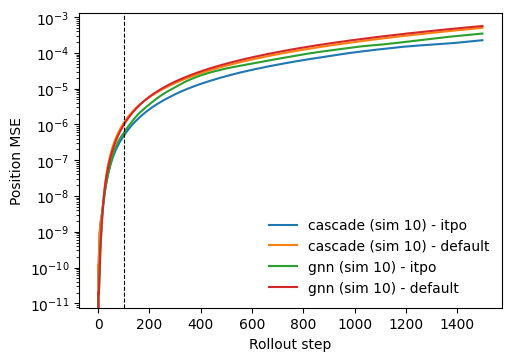

In [7]:
long_rows = []
long_mse = {}   # (simulator, mode) -> MSE per step
rollouts = {}   # (simulator, mode) -> frames
with torch.no_grad():
    for simulator, sim_idx in best_sims.items():
        for mode in ("itpo", "default"):
            row, pos_mse, rollout = evaluate(simulator, mode, sim_idx, gif_steps)
            long_rows.append(row)
            long_mse[(simulator, mode)] = pos_mse
            rollouts[(simulator, mode)] = to_frames(rollout)

long_results = pd.DataFrame(long_rows)
display(long_results)

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), layout="constrained")
for (simulator, mode), pos_mse in long_mse.items():
    ax.plot(pos_mse, label=f"{simulator} (sim {best_sims[simulator]}) - {mode}")
ax.axvline(search_steps, color="black", linestyle="--", linewidth=0.8)
ax.set_yscale("log")
ax.set_xlabel("Rollout step")
ax.set_ylabel("Position MSE")
ax.legend(frameon=False)
plt.show()

### GIFs

Adapted from `gnn_optimization/animation.ipynb`: GT in black, prediction in red on top, each with its own periodic box.

In [8]:
def get_pbc_segments(pos, edges, box):
    p1 = pos[edges[:, 0]]
    p2 = pos[edges[:, 1]]
    delta = p2 - p1

    # Use the specific box dimensions of the current frame
    shift_x = np.round(delta[:, 0] / box[0]) * box[0]
    shift_y = np.round(delta[:, 1] / box[1]) * box[1]
    shifts = np.stack([shift_x, shift_y], axis=1)

    is_pbc = np.any(shifts != 0, axis=1)

    normal_segs = np.stack([p1[~is_pbc], p2[~is_pbc]], axis=1)
    pbc_seg1 = np.stack([p1[is_pbc], p2[is_pbc] - shifts[is_pbc]], axis=1)

    if len(pbc_seg1) > 0:
        return np.concatenate([normal_segs, pbc_seg1], axis=0)
    return normal_segs


def make_overlay_gif(gt: list[dict], pred: list[dict], title: str, out_path: str, duration: float = 3.0, fps: int = 50):
    # GIF frame delays are in 1/100 s and browsers slow down delays below 20 ms, so subsample frames instead
    frame_ids = np.unique(np.linspace(0, len(gt) - 1, int(duration * fps)).round().astype(int))

    all_boxes = np.array([f["box"] for f in gt + pred])
    max_box = all_boxes.max(axis=0)

    # Establish viewport boundaries based on the largest possible box size
    global_origin = -max_box / 2.0
    pad_x, pad_y = max_box[0] * 0.15, max_box[1] * 0.15

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(global_origin[0] - pad_x, global_origin[0] + max_box[0] + pad_x)
    ax.set_ylim(global_origin[1] - pad_y, global_origin[1] + max_box[1] + pad_y)
    ax.set_aspect("equal")
    ax.axis("off")

    layers = []
    for frames, color, alpha, label, z in ((gt, "black", 1.0, "GT", 1), (pred, "tab:red", 0.7, "Predicted", 4)):
        first = frames[0]
        rect = patches.Rectangle(-first["box"] / 2.0, first["box"][0], first["box"][1], linewidth=0.8,
                                 edgecolor=color, facecolor="none", linestyle="-" if label == "GT" else "--", zorder=z)
        ax.add_patch(rect)
        edge_collection = LineCollection(get_pbc_segments(first["pos"], first["edges"], first["box"]),
                                         linewidths=1.0, colors=color, alpha=alpha, zorder=z + 1)
        ax.add_collection(edge_collection)
        edge_collection.set_clip_path(rect)
        node_scatter = ax.scatter(first["pos"][:, 0], first["pos"][:, 1], s=12, color=color, alpha=alpha, zorder=z + 2, label=label)
        layers.append((frames, rect, edge_collection, node_scatter))

    ax.legend(loc="upper right", frameon=False)
    ax.set_title(title)
    step_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")

    def update(frame_idx):
        frame_idx = frame_ids[frame_idx]
        artists = []
        for frames, rect, edge_collection, node_scatter in layers:
            frame = frames[frame_idx]
            rect.set_xy(-frame["box"] / 2.0)
            rect.set_width(frame["box"][0])
            rect.set_height(frame["box"][1])
            node_scatter.set_offsets(frame["pos"])
            edge_collection.set_segments(get_pbc_segments(frame["pos"], frame["edges"], frame["box"]))
            artists += [rect, edge_collection, node_scatter]
        mse = np.mean((layers[0][0][frame_idx]["pos"] - layers[1][0][frame_idx]["pos"]) ** 2)
        step_text.set_text(f"step {frame_idx}   MSE {mse:.2e}")
        return artists + [step_text]

    anim = FuncAnimation(fig, update, frames=len(frame_ids), interval=1000 / fps, blit=True)
    anim.save(out_path, writer=PillowWriter(fps=fps), dpi=100)
    plt.close(fig)

In [9]:
out_dir = "rollout_gifs"
os.makedirs(out_dir, exist_ok=True)

simulator_names = {"cascade": "Simulator cascade", "gnn": "Bootstrapped GNN (h3)"}
gif_paths = []
for simulator, sim_idx in best_sims.items():
    gt_frames = to_frames(data["test"][sim_idx][:gif_steps + 1])
    for mode in ("itpo", "default"):
        row = long_results[(long_results["simulator"] == simulator) & (long_results["mode"] == mode)].iloc[0]
        title = (f"{simulator_names[simulator]}, {'ITPO' if mode == 'itpo' else 'no ITPO'}, new_node_optimized auxetic sim {sim_idx}\n"
                 fr"$\nu_{{gt}}$={row.gt_p:.3f}, $\nu_{{pred}}$={row.pred_p:.3f}, final MSE={row.final_mse:.2e}")
        for duration in gif_durations:
            out_path = os.path.join(out_dir, f"new_auxetic_{simulator}_{mode}_sim{sim_idx}_{gif_steps}steps_{duration:g}s_50fps.gif")
            make_overlay_gif(gt_frames, rollouts[(simulator, mode)], title, out_path, duration=duration)
            gif_paths.append(out_path)
            print(f"Saved {out_path}")

Saved rollout_gifs/new_auxetic_cascade_itpo_sim10_1499steps_2s_50fps.gif


Saved rollout_gifs/new_auxetic_cascade_itpo_sim10_1499steps_1s_50fps.gif


Saved rollout_gifs/new_auxetic_cascade_default_sim10_1499steps_2s_50fps.gif


Saved rollout_gifs/new_auxetic_cascade_default_sim10_1499steps_1s_50fps.gif


Saved rollout_gifs/new_auxetic_gnn_itpo_sim10_1499steps_2s_50fps.gif


Saved rollout_gifs/new_auxetic_gnn_itpo_sim10_1499steps_1s_50fps.gif


Saved rollout_gifs/new_auxetic_gnn_default_sim10_1499steps_2s_50fps.gif


Saved rollout_gifs/new_auxetic_gnn_default_sim10_1499steps_1s_50fps.gif


In [ ]:
for path in gif_paths:
    display(Image(filename=path))